In [38]:
# !pip install catboost

In [39]:
import warnings
warnings.filterwarnings("ignore")

# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import zscore

# Data Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from imblearn.over_sampling import SMOTE

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [40]:
df=pd.read_csv("data/raw.csv")

In [41]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
df["Churn"]=df["Churn"].replace({"Yes":1,"No":0})

In [43]:
X = df.drop(columns=['customerID',"PhoneService","Churn"],axis=1)
y = df['Churn']

In [44]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

In [45]:
le=LabelEncoder()
for i in cat_features:
    X[i]=le.fit_transform(X[i])

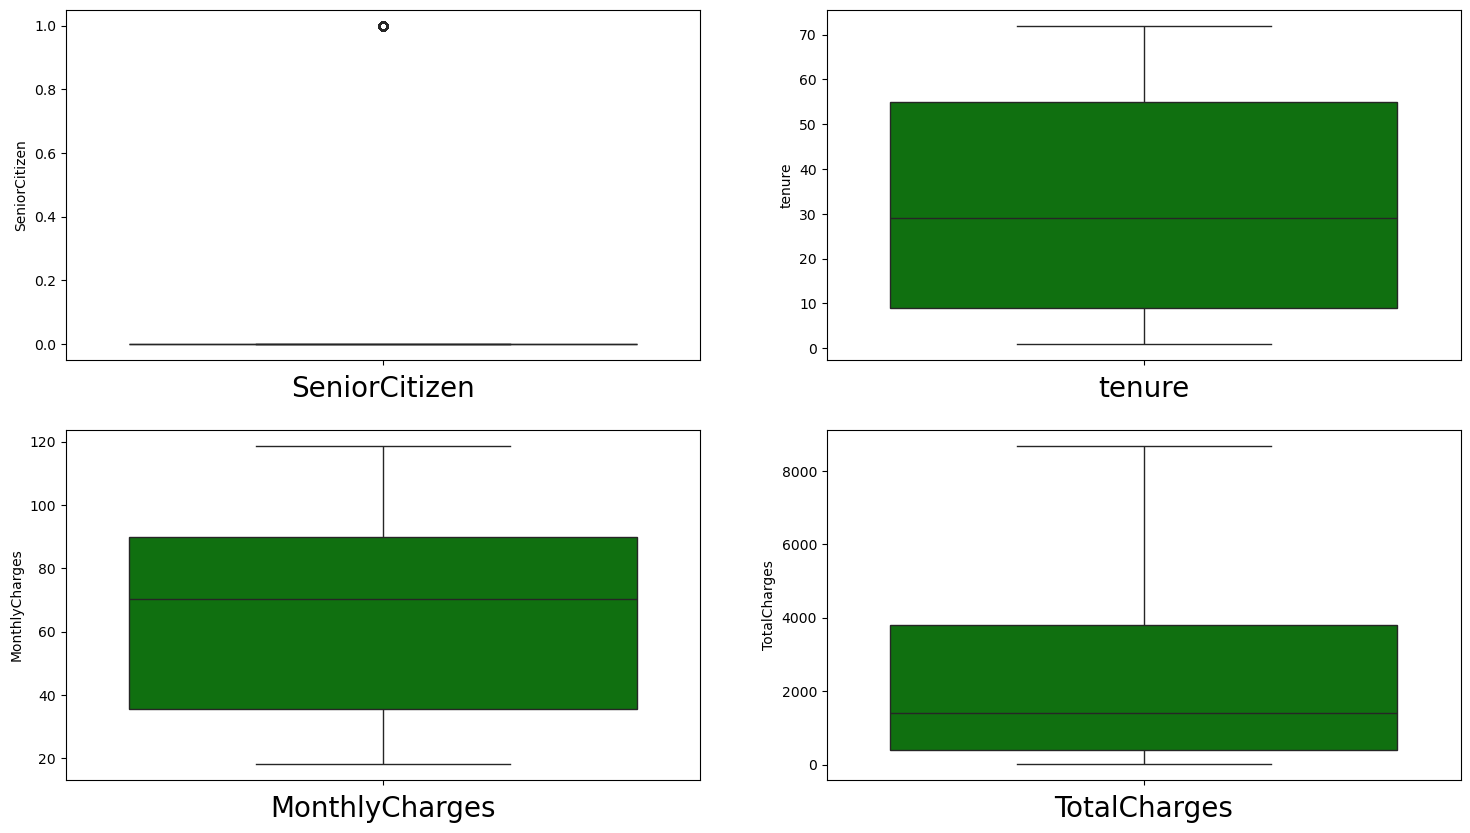

In [46]:
plt.figure(figsize=(18,10),facecolor="white")
plotnumber=1

for column in num_features:
    if plotnumber:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(X[column],color="g")
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [47]:
z=np.abs(zscore(X))
df1=X[(z<3).all(axis=1)]
print(df1.shape)
print(X.shape)
X=df1.copy()

(7032, 18)
(7032, 18)


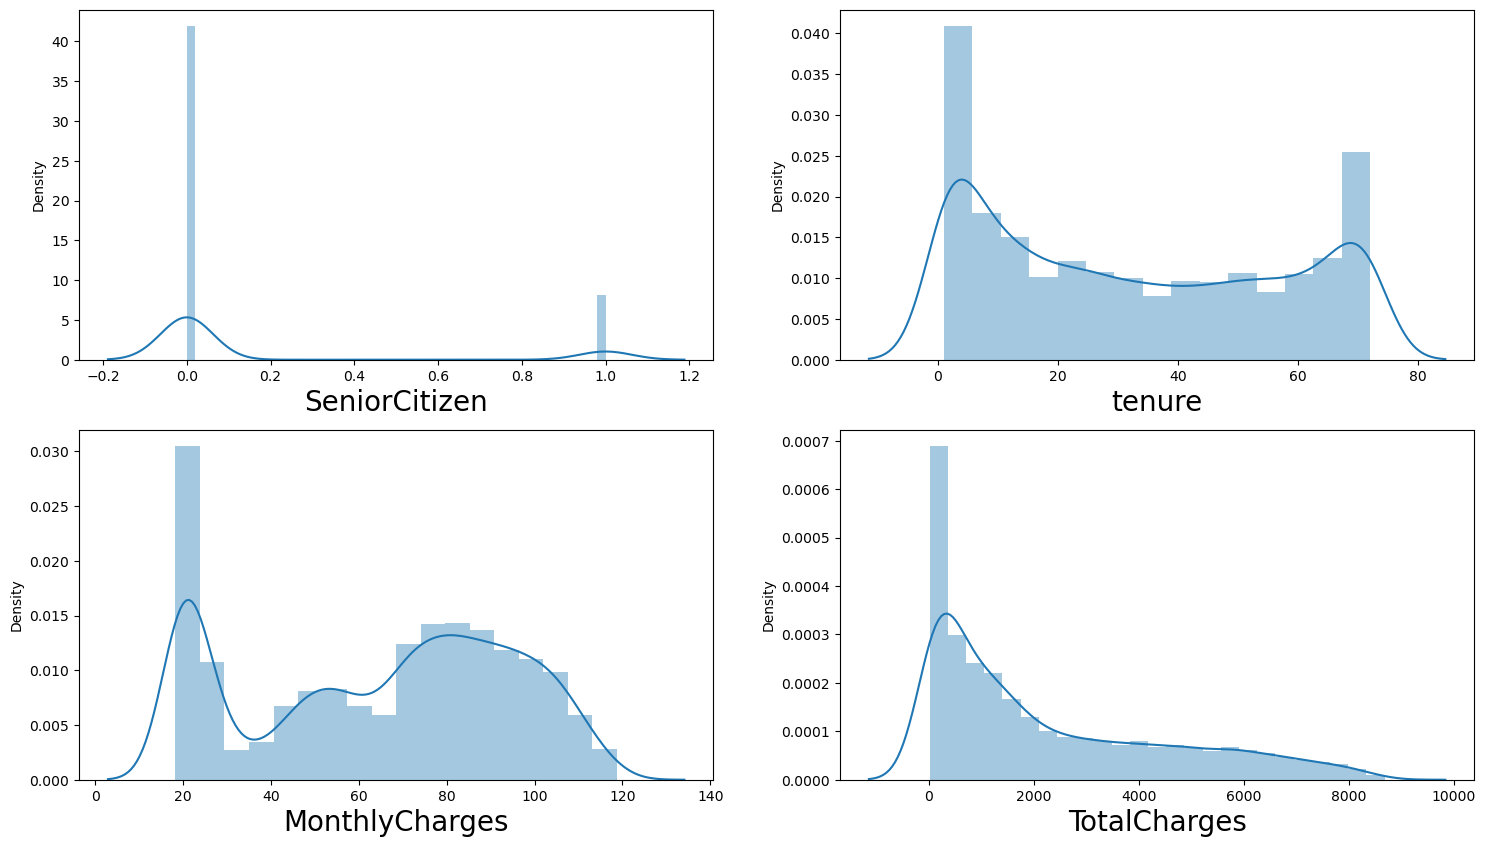

In [48]:
plt.figure(figsize=(18,10),facecolor="white")
plotnumber=1

for column in num_features:
    if plotnumber:
        ax=plt.subplot(2,2,plotnumber)
        sns.distplot(X[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [49]:
X.skew()

gender             -0.018776
SeniorCitizen       1.831103
Partner             0.070024
Dependents          0.880908
tenure              0.237731
MultipleLines       0.118623
InternetService     0.205704
OnlineSecurity      0.418619
OnlineBackup        0.184089
DeviceProtection    0.188013
TechSupport         0.403966
StreamingTV         0.029366
StreamingMovies     0.013851
Contract            0.635149
PaperlessBilling   -0.377503
PaymentMethod      -0.169388
MonthlyCharges     -0.222103
TotalCharges        0.961642
dtype: float64

In [50]:
skew=["TotalCharges"]
skewness=PowerTransformer(method="yeo-johnson")
X[skew]=skewness.fit_transform(X[skew].values)

In [51]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [52]:
oversample=SMOTE()
X,y=oversample.fit_resample(X,y)

In [53]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.850000,-1.810069
1,1,0,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.950000,0.254257
2,1,0,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.850000,-1.386091
3,1,0,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.300000,0.233220
4,0,0,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.700000,-1.248808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10321,0,0,0,0,45,0,1,0,1,0,0,2,2,0,0,1,95.633044,1.014860
10322,1,0,0,0,33,2,1,0,0,0,0,0,0,0,0,1,75.055614,0.458566
10323,0,0,1,1,19,1,1,0,0,2,2,2,2,0,0,2,103.222875,0.311691
10324,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,3,70.863645,-1.541600


In [54]:
y.value_counts()

Churn
0    5163
1    5163
Name: count, dtype: int64

In [55]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((8260, 18), (2066, 18))

In [57]:
def evaluate_model(true,predicted):
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    return accuracy,precision,recall,f1

In [58]:
models={
    "Logestic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boosting":GradientBoostingClassifier(),
    "AdaBoost":AdaBoostClassifier(),
    "XGBoost":XGBClassifier(),
    "CatBoost":CatBoostClassifier(verbose=False),
    "KNN":KNeighborsClassifier(),
    "SVM":SVC()

}

model_list=[]
accuracy_list=[]
precision_list = []
recall_list = []
f1_list = []

for i in range(len(list(models))):
    model=list(models.values())[i]
    model_name=list(models.keys())[i]
    model.fit(X_train,y_train) #train model 

    #Make Prediction
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)


    # Evaluate Train and Test dataset
    train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(y_train,y_train_pred)

    test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(
        y_test,
        y_test_pred
    )

    model_list.append(model_name)
    accuracy_list.append(test_accuracy)
    precision_list.append(test_precision)
    recall_list.append(test_recall)
    f1_list.append(test_f1)

    print("="*60)
    print(model_name)
    print("="*60)

    print("Training Performance")
    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1 Score : {train_f1:.4f}")

    print("-"*60)

    print("Testing Performance")
    print(f"Accuracy : {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_test_pred))
    print()


Logestic Regression
Training Performance
Accuracy : 0.7920
Precision: 0.7734
Recall   : 0.8266
F1 Score : 0.7991
------------------------------------------------------------
Testing Performance
Accuracy : 0.7909
Precision: 0.7736
Recall   : 0.8202
F1 Score : 0.7962

Confusion Matrix
[[790 247]
 [185 844]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.76      0.79      1037
           1       0.77      0.82      0.80      1029

    accuracy                           0.79      2066
   macro avg       0.79      0.79      0.79      2066
weighted avg       0.79      0.79      0.79      2066


Decision Tree
Training Performance
Accuracy : 0.9992
Precision: 0.9998
Recall   : 0.9985
F1 Score : 0.9992
------------------------------------------------------------
Testing Performance
Accuracy : 0.7778
Precision: 0.7679
Recall   : 0.7940
F1 Score : 0.7807

Confusion Matrix
[[790 247]
 [212 817]]

Classification Report
              prec

In [59]:
results = pd.DataFrame({
    "Model": model_list,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1 Score": f1_list
})

results = results.sort_values(by="F1 Score", ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.844627,0.841040,0.848397,0.844702
5,XGBoost,0.837851,0.829222,0.849368,0.839174
6,CatBoost,0.835431,0.825307,0.849368,0.837165
3,Gradient Boosting,0.823330,0.801270,0.858115,0.828719
8,SVM,0.816554,0.791219,0.858115,0.823310
4,AdaBoost,0.802517,0.775510,0.849368,0.810761
7,KNN,0.786060,0.752799,0.849368,0.798174
0,Logestic Regression,0.790900,0.773602,0.820214,0.796226
1,Decision Tree,0.777832,0.767857,0.793975,0.780698


In [60]:
rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}
xg_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

In [61]:
randomcv_models=[
                 ("RF",RandomForestClassifier(),rf_params),
    ("XG",XGBClassifier(),xg_params)
]

In [70]:
model_param={}
for name,model,params in randomcv_models:
    random=RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=100,cv=5,verbose=2,n_jobs=-1)
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_
for model_name in model_param:
    print(f"---------------------------- Best Params for {model_name} ---------------------------")
    print(model_param[model_name])

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
---------------------------- Best Params for RF ---------------------------
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'entropy', 'bootstrap': False}
---------------------------- Best Params for XG ---------------------------
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [78]:
models={
    
        "Random Forest":RandomForestClassifier(n_estimators= 100, min_samples_split = 2, min_samples_leaf=2, max_features= 'sqrt', max_depth= 30, criterion='entropy', bootstrap = False),
        "XGBoost":XGBClassifier(subsample= 1.0, reg_lambda = 1, reg_alpha=0, n_estimators = 500, min_child_weight= 1, max_depth=7, learning_rate=0.1, gamma= 0.1, colsample_bytree= 0.6)
}




for i in range(len(list(models))):
    model=list(models.values())[i]
    model_name=list(models.keys())[i]
    model.fit(X_train,y_train) #train model 

    #Make Prediction
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)


    # Evaluate Train and Test dataset
    train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(y_train,y_train_pred)

    test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(
        y_test,
        y_test_pred
    )

    

    print("="*60)
    print(model_name)
    print("="*60)

    print("Training Performance")
    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1 Score : {train_f1:.4f}")

    print("-"*60)

    print("Testing Performance")
    print(f"Accuracy : {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")

    



Random Forest
Training Performance
Accuracy : 0.9915
Precision: 0.9880
Recall   : 0.9952
F1 Score : 0.9916
------------------------------------------------------------
Testing Performance
Accuracy : 0.8446
Precision: 0.8384
Recall   : 0.8523
F1 Score : 0.8453
XGBoost
Training Performance
Accuracy : 0.9499
Precision: 0.9314
Recall   : 0.9715
F1 Score : 0.9510
------------------------------------------------------------
Testing Performance
Accuracy : 0.8403
Precision: 0.8300
Recall   : 0.8542
F1 Score : 0.8420


In [79]:
import joblib

rf_model = models["Random Forest"]

joblib.dump(rf_model, "random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [80]:
loaded_model = joblib.load("random_forest_model.pkl")

y_pred = loaded_model.predict(X_test)